In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]

Python executable:
C:\Users\Elvis\documents\Analysis Project\Data-Analytics-Capstone\.venv\Scripts\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import scipy
import sqlalchemy
import psycopg2

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)
print("Psycopg2: installed")

Pandas: 3.0.5
NumPy: 2.5.1
Matplotlib: 3.11.1
Scikit-learn: 1.9.0
SciPy: 1.18.0
SQLAlchemy: 2.0.51
Psycopg2: installed


In [4]:
import psycopg2
import getpass

# Ask for the PostgreSQL password without displaying it
password = getpass.getpass("Enter your PostgreSQL password: ")

try:
    connection = psycopg2.connect(
        host="localhost",
        port=5432,
        database="analytics_capstone",
        user="postgres",
        password=password
    )

    print("SUCCESS: Jupyter is connected to PostgreSQL!")

    connection.close()

except psycopg2.Error as error:
    print("CONNECTION FAILED:")
    print(error)

Enter your PostgreSQL password:  ········


SUCCESS: Jupyter is connected to PostgreSQL!


In [5]:
import psycopg2
import getpass

password = getpass.getpass("Enter your PostgreSQL password: ")

connection = psycopg2.connect(
    host="localhost",
    port=5432,
    database="analytics_capstone",
    user="postgres",
    password=password
)

cursor = connection.cursor()

cursor.execute("""
    SELECT
        current_database(),
        current_user,
        version();
""")

result = cursor.fetchone()

print("Database:", result[0])
print("User:", result[1])
print("PostgreSQL:", result[2])

cursor.close()
connection.close()

Enter your PostgreSQL password:  ········


Database: analytics_capstone
User: postgres
PostgreSQL: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


In [2]:
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

print("Environment variables loaded successfully.")

Environment variables loaded successfully.


In [4]:
print("Host:", os.getenv("DB_HOST"))
print("Port:", os.getenv("DB_PORT"))
print("Database:", os.getenv("DB_NAME"))
print("User:", os.getenv("DB_USER"))
print("Password loaded:", bool(os.getenv("DB_PASSWORD")))

Host: localhost
Port: 5432
Database: analytics_capstone
User: postgres
Password loaded: True


In [5]:
import psycopg2
import os

connection = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

print("SUCCESS: Secure PostgreSQL connection established!")

SUCCESS: Secure PostgreSQL connection established!


In [6]:
cursor = connection.cursor()

cursor.execute("""
    SELECT
        current_database(),
        current_user,
        version();
""")

database, user, version = cursor.fetchone()

print("Database:", database)
print("User:", user)
print("PostgreSQL:", version)

Database: analytics_capstone
User: postgres
PostgreSQL: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


In [11]:
cursor.close()
connection.close()

print("Database connection closed successfully.")

Database connection closed successfully.


In [12]:
import psycopg2
import os

connection = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

cursor = connection.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS project_test (
        id SERIAL PRIMARY KEY,
        name VARCHAR(100),
        value NUMERIC
    );
""")

connection.commit()

print("SUCCESS: project_test table created!")

SUCCESS: project_test table created!


In [13]:
cursor.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
""")

tables = cursor.fetchall()

print("Tables in analytics_capstone:")

for table in tables:
    print("-", table[0])

Tables in analytics_capstone:
- project_test


In [14]:
cursor.execute("DROP TABLE IF EXISTS project_test;")
connection.commit()

print("Temporary test table removed.")

Temporary test table removed.


In [15]:
cursor.close()
connection.close()

print("Database connection closed successfully.")

Database connection closed successfully.


In [7]:
import pandas as pd

Final_data = pd.read_csv(
    "../processed/kenya_economic_data_2015_2024.csv"
)

display(Final_data)

,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent
0,2015,6884327.0,5.000000,1520817.0,6.582154
1,2016,7594064.0,4.200000,1472621.0,6.297250
2,2017,8483396.0,3.800000,1687833.0,8.005650
3,2018,9340307.0,5.600000,1783811.0,4.689806
4,2019,10237727.0,5.100000,1941234.0,5.239638
5,2020,10715070.0,-0.300000,2070321.0,5.405162
6,2021,12027662.0,7.600000,2367797.0,6.107936
7,2022,13489642.0,4.859979,2509782.0,7.659863
8,2023,15033610.0,5.719993,2625440.0,7.671396
9,2024,16224478.0,4.724740,2845545.0,4.489789


In [8]:
Final_data.shape

(10, 5)

In [9]:
unemployment_data = pd.DataFrame({
    "year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "unemployment_rate_percent": [
        2.762, 2.757, 3.542, 4.284, 5.014,
        5.613, 5.693, 5.565, 5.409, 5.487
    ]
})

display(unemployment_data)

,year,unemployment_rate_percent
0,2015,2.762
1,2016,2.757
2,2017,3.542
3,2018,4.284
4,2019,5.014
5,2020,5.613
6,2021,5.693
7,2022,5.565
8,2023,5.409
9,2024,5.487


In [10]:
unemployment_values = [
    2.762,
    2.757,
    3.542,
    4.284,
    5.014,
    5.613,
    5.693,
    5.565,
    5.409,
    5.487
]

In [11]:
display(unemployment_values)

[2.762, 2.757, 3.542, 4.284, 5.014, 5.613, 5.693, 5.565, 5.409, 5.487]

In [12]:
unemployment_data = pd.DataFrame({
    "unemployment_rate_percent": [
        2.762,
        2.757,
        3.542,
        4.284,
        5.014,
        5.613,
        5.693,
        5.565,
        5.409,
        5.487
    ]
})

display(unemployment_data)

,unemployment_rate_percent
0,2.762
1,2.757
2,3.542
3,4.284
4,5.014
5,5.613
6,5.693
7,5.565
8,5.409
9,5.487


In [13]:
Final_data["unemployment_rate_percent"] = unemployment_data[
    "unemployment_rate_percent"
].values

In [14]:
display(Final_data)

,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
0,2015,6884327.0,5.000000,1520817.0,6.582154,2.762
1,2016,7594064.0,4.200000,1472621.0,6.297250,2.757
2,2017,8483396.0,3.800000,1687833.0,8.005650,3.542
3,2018,9340307.0,5.600000,1783811.0,4.689806,4.284
4,2019,10237727.0,5.100000,1941234.0,5.239638,5.014
5,2020,10715070.0,-0.300000,2070321.0,5.405162,5.613
6,2021,12027662.0,7.600000,2367797.0,6.107936,5.693
7,2022,13489642.0,4.859979,2509782.0,7.659863,5.565
8,2023,15033610.0,5.719993,2625440.0,7.671396,5.409
9,2024,16224478.0,4.724740,2845545.0,4.489789,5.487


In [15]:
print(Final_data.columns.tolist())
print(Final_data.shape)

['year', 'gdp_current_ksh_million', 'gdp_growth_percent', 'gfcf_ksh_million', 'inflation_rate_percent', 'unemployment_rate_percent']
(10, 6)


In [16]:
Final_data.to_csv(
    "../processed/kenya_economic_data_2015_2024.csv",
    index=False
)

In [17]:
import pandas as pd

Final_data = pd.read_csv(
    "../processed/kenya_economic_data_2015_2024.csv"
)

display(Final_data)

,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
0,2015,6884327.0,5.000000,1520817.0,6.582154,2.762
1,2016,7594064.0,4.200000,1472621.0,6.297250,2.757
2,2017,8483396.0,3.800000,1687833.0,8.005650,3.542
3,2018,9340307.0,5.600000,1783811.0,4.689806,4.284
4,2019,10237727.0,5.100000,1941234.0,5.239638,5.014
5,2020,10715070.0,-0.300000,2070321.0,5.405162,5.613
6,2021,12027662.0,7.600000,2367797.0,6.107936,5.693
7,2022,13489642.0,4.859979,2509782.0,7.659863,5.565
8,2023,15033610.0,5.719993,2625440.0,7.671396,5.409
9,2024,16224478.0,4.724740,2845545.0,4.489789,5.487


In [18]:
print("Host:", os.getenv("DB_HOST"))
print("Port:", os.getenv("DB_PORT"))
print("Database:", os.getenv("DB_NAME"))
print("User:", os.getenv("DB_USER"))
print("Password loaded:", bool(os.getenv("DB_PASSWORD")))

Host: localhost
Port: 5432
Database: analytics_capstone
User: postgres
Password loaded: True


In [19]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("SELECT version();"))
    print("PostgreSQL connection successful!")
    print(result.fetchone()[0])

NameError: name 'engine' is not defined

In [20]:
import psycopg2
import os

connection = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

print("SUCCESS: Secure PostgreSQL connection established!")

SUCCESS: Secure PostgreSQL connection established!


In [21]:
cursor = connection.cursor()

cursor.execute("""
    SELECT
        current_database(),
        current_user,
        version();
""")

database, user, version = cursor.fetchone()

print("Database:", database)
print("User:", user)
print("PostgreSQL:", version)

Database: analytics_capstone
User: postgres
PostgreSQL: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


In [22]:
import pandas as pd

Final_data = pd.read_csv(
    "../processed/kenya_economic_data_2015_2024.csv"
)

display(Final_data)

,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
0,2015,6884327.0,5.000000,1520817.0,6.582154,2.762
1,2016,7594064.0,4.200000,1472621.0,6.297250,2.757
2,2017,8483396.0,3.800000,1687833.0,8.005650,3.542
3,2018,9340307.0,5.600000,1783811.0,4.689806,4.284
4,2019,10237727.0,5.100000,1941234.0,5.239638,5.014
5,2020,10715070.0,-0.300000,2070321.0,5.405162,5.613
6,2021,12027662.0,7.600000,2367797.0,6.107936,5.693
7,2022,13489642.0,4.859979,2509782.0,7.659863,5.565
8,2023,15033610.0,5.719993,2625440.0,7.671396,5.409
9,2024,16224478.0,4.724740,2845545.0,4.489789,5.487


In [23]:
from sqlalchemy import create_engine

In [24]:
type(connection)

psycopg2.extensions.connection

In [25]:
cursor = connection.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS kenya_economic_data (
        year INTEGER,
        gdp_current_ksh_million NUMERIC,
        gdp_growth_percent NUMERIC,
        gfcf_ksh_million NUMERIC,
        inflation_rate_percent NUMERIC,
        unemployment_rate_percent NUMERIC
    );
""")

connection.commit()

print("Table created successfully.")

Table created successfully.


In [26]:
insert_query = """
    INSERT INTO kenya_economic_data (
        year,
        gdp_current_ksh_million,
        gdp_growth_percent,
        gfcf_ksh_million,
        inflation_rate_percent,
        unemployment_rate_percent
    )
    VALUES (%s, %s, %s, %s, %s, %s);
"""

for row in Final_data.itertuples(index=False, name=None):
    cursor.execute(insert_query, row)

connection.commit()

print("Data successfully imported into PostgreSQL.")

Data successfully imported into PostgreSQL.


In [27]:
cursor.execute("""
    SELECT *
    FROM kenya_economic_data
    ORDER BY year;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

(2015, Decimal('6884327.0'), Decimal('5.0'), Decimal('1520817.0'), Decimal('6.582154292847786'), Decimal('2.762'))
(2016, Decimal('7594064.0'), Decimal('4.2'), Decimal('1472621.0'), Decimal('6.297249538146249'), Decimal('2.757'))
(2017, Decimal('8483396.0'), Decimal('3.8'), Decimal('1687833.0'), Decimal('8.005649677099447'), Decimal('3.542'))
(2018, Decimal('9340307.0'), Decimal('5.6'), Decimal('1783811.0'), Decimal('4.689806467763299'), Decimal('4.284'))
(2019, Decimal('10237727.0'), Decimal('5.1'), Decimal('1941234.0'), Decimal('5.239637957647923'), Decimal('5.014'))
(2020, Decimal('10715070.0'), Decimal('-0.3'), Decimal('2070321.0'), Decimal('5.40516207933392'), Decimal('5.613'))
(2021, Decimal('12027662.0'), Decimal('7.6'), Decimal('2367797.0'), Decimal('6.107936036591763'), Decimal('5.693'))
(2022, Decimal('13489642.0'), Decimal('4.8599790442596325'), Decimal('2509782.0'), Decimal('7.659862682722239'), Decimal('5.565'))
(2023, Decimal('15033610.0'), Decimal('5.719992943902841'), D

In [28]:
cursor.execute("""
    SELECT COUNT(*)
    FROM kenya_economic_data;
""")

print("Number of rows:", cursor.fetchone()[0])

Number of rows: 10


In [29]:
cursor.execute("""
    SELECT year, COUNT(*)
    FROM kenya_economic_data
    GROUP BY year
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2015, 1)
(2016, 1)
(2017, 1)
(2018, 1)
(2019, 1)
(2020, 1)
(2021, 1)
(2022, 1)
(2023, 1)
(2024, 1)


In [30]:
cursor.execute("""
    SELECT *
    FROM kenya_economic_data
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2015, Decimal('6884327.0'), Decimal('5.0'), Decimal('1520817.0'), Decimal('6.582154292847786'), Decimal('2.762'))
(2016, Decimal('7594064.0'), Decimal('4.2'), Decimal('1472621.0'), Decimal('6.297249538146249'), Decimal('2.757'))
(2017, Decimal('8483396.0'), Decimal('3.8'), Decimal('1687833.0'), Decimal('8.005649677099447'), Decimal('3.542'))
(2018, Decimal('9340307.0'), Decimal('5.6'), Decimal('1783811.0'), Decimal('4.689806467763299'), Decimal('4.284'))
(2019, Decimal('10237727.0'), Decimal('5.1'), Decimal('1941234.0'), Decimal('5.239637957647923'), Decimal('5.014'))
(2020, Decimal('10715070.0'), Decimal('-0.3'), Decimal('2070321.0'), Decimal('5.40516207933392'), Decimal('5.613'))
(2021, Decimal('12027662.0'), Decimal('7.6'), Decimal('2367797.0'), Decimal('6.107936036591763'), Decimal('5.693'))
(2022, Decimal('13489642.0'), Decimal('4.8599790442596325'), Decimal('2509782.0'), Decimal('7.659862682722239'), Decimal('5.565'))
(2023, Decimal('15033610.0'), Decimal('5.719992943902841'), D

In [31]:
cursor.execute("""
    SELECT COUNT(*) AS total_years
    FROM kenya_economic_data;
""")

print("Total observations:", cursor.fetchone()[0])

Total observations: 10


In [32]:
cursor.execute("""
    SELECT
        COUNT(*) AS observations,
        AVG(gdp_current_ksh_million) AS avg_gdp,
        MIN(gdp_current_ksh_million) AS min_gdp,
        MAX(gdp_current_ksh_million) AS max_gdp,
        AVG(gdp_growth_percent) AS avg_gdp_growth,
        MIN(gdp_growth_percent) AS min_gdp_growth,
        MAX(gdp_growth_percent) AS max_gdp_growth,
        AVG(gfcf_ksh_million) AS avg_gfcf,
        AVG(inflation_rate_percent) AS avg_inflation,
        AVG(unemployment_rate_percent) AS avg_unemployment
    FROM kenya_economic_data;
""")

result = cursor.fetchone()

for value in result:
    print(value)

10
11003028.300000000000
6884327.0
16224478.0
4.6304711516498216
-0.3
7.6
2082520.100000000000
6.2148643614881128
4.6126000000000000


In [33]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent
    FROM kenya_economic_data
    ORDER BY gdp_growth_percent DESC
    LIMIT 1;
""")

print("Highest GDP growth:", cursor.fetchone())

Highest GDP growth: (2021, Decimal('7.6'))


In [34]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent
    FROM kenya_economic_data
    ORDER BY gdp_growth_percent ASC
    LIMIT 1;
""")

print("Lowest GDP growth:", cursor.fetchone())

Lowest GDP growth: (2020, Decimal('-0.3'))


In [35]:
cursor.execute("""
    SELECT
        year,
        inflation_rate_percent
    FROM kenya_economic_data
    ORDER BY inflation_rate_percent DESC
    LIMIT 1;
""")

print("Highest inflation:", cursor.fetchone())

Highest inflation: (2017, Decimal('8.005649677099447'))


In [36]:
cursor.execute("""
    SELECT
        year,
        inflation_rate_percent
    FROM kenya_economic_data
    ORDER BY inflation_rate_percent ASC
    LIMIT 1;
""")

print("Lowest inflation:", cursor.fetchone())

Lowest inflation: (2024, Decimal('4.489788542434479'))


In [37]:
cursor.execute("""
    SELECT
        year,
        unemployment_rate_percent
    FROM kenya_economic_data
    ORDER BY unemployment_rate_percent DESC
    LIMIT 1;
""")

print("Highest unemployment:", cursor.fetchone())

Highest unemployment: (2021, Decimal('5.693'))


In [38]:
cursor.execute("""
    SELECT
        year,
        unemployment_rate_percent
    FROM kenya_economic_data
    ORDER BY unemployment_rate_percent ASC
    LIMIT 1;
""")

print("Lowest unemployment:", cursor.fetchone())

Lowest unemployment: (2016, Decimal('2.757'))


In [39]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent
    FROM kenya_economic_data
    WHERE gdp_growth_percent < 0
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2020, Decimal('-0.3'))


In [40]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent
    FROM kenya_economic_data
    WHERE gdp_growth_percent > 5
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2018, Decimal('5.6'))
(2019, Decimal('5.1'))
(2021, Decimal('7.6'))
(2023, Decimal('5.719992943902841'))


In [41]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent,
        inflation_rate_percent
    FROM kenya_economic_data
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2015, Decimal('5.0'), Decimal('6.582154292847786'))
(2016, Decimal('4.2'), Decimal('6.297249538146249'))
(2017, Decimal('3.8'), Decimal('8.005649677099447'))
(2018, Decimal('5.6'), Decimal('4.689806467763299'))
(2019, Decimal('5.1'), Decimal('5.239637957647923'))
(2020, Decimal('-0.3'), Decimal('5.40516207933392'))
(2021, Decimal('7.6'), Decimal('6.107936036591763'))
(2022, Decimal('4.8599790442596325'), Decimal('7.659862682722239'))
(2023, Decimal('5.719992943902841'), Decimal('7.671396340294023'))
(2024, Decimal('4.724739528335742'), Decimal('4.489788542434479'))


In [42]:
cursor.execute("""
    SELECT
        year,
        gdp_growth_percent,
        CASE
            WHEN gdp_growth_percent < 0 THEN 'Negative Growth'
            WHEN gdp_growth_percent < 5 THEN 'Moderate Growth'
            ELSE 'High Growth'
        END AS growth_category
    FROM kenya_economic_data
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2015, Decimal('5.0'), 'High Growth')
(2016, Decimal('4.2'), 'Moderate Growth')
(2017, Decimal('3.8'), 'Moderate Growth')
(2018, Decimal('5.6'), 'High Growth')
(2019, Decimal('5.1'), 'High Growth')
(2020, Decimal('-0.3'), 'Negative Growth')
(2021, Decimal('7.6'), 'High Growth')
(2022, Decimal('4.8599790442596325'), 'Moderate Growth')
(2023, Decimal('5.719992943902841'), 'High Growth')
(2024, Decimal('4.724739528335742'), 'Moderate Growth')


In [43]:
cursor.execute("""
    SELECT
        CASE
            WHEN gdp_growth_percent < 0 THEN 'Negative Growth'
            WHEN gdp_growth_percent < 5 THEN 'Moderate Growth'
            ELSE 'High Growth'
        END AS growth_category,
        COUNT(*) AS number_of_years
    FROM kenya_economic_data
    GROUP BY growth_category
    ORDER BY number_of_years DESC;
""")

for row in cursor.fetchall():
    print(row)

('High Growth', 5)
('Moderate Growth', 4)
('Negative Growth', 1)


In [44]:
cursor.execute("""
    SELECT
        year,
        ROUND(gdp_current_ksh_million, 2) AS gdp,
        ROUND(gdp_growth_percent, 2) AS gdp_growth,
        ROUND(gfcf_ksh_million, 2) AS gfcf,
        ROUND(inflation_rate_percent, 2) AS inflation,
        ROUND(unemployment_rate_percent, 2) AS unemployment
    FROM kenya_economic_data
    ORDER BY year;
""")

for row in cursor.fetchall():
    print(row)

(2015, Decimal('6884327.00'), Decimal('5.00'), Decimal('1520817.00'), Decimal('6.58'), Decimal('2.76'))
(2016, Decimal('7594064.00'), Decimal('4.20'), Decimal('1472621.00'), Decimal('6.30'), Decimal('2.76'))
(2017, Decimal('8483396.00'), Decimal('3.80'), Decimal('1687833.00'), Decimal('8.01'), Decimal('3.54'))
(2018, Decimal('9340307.00'), Decimal('5.60'), Decimal('1783811.00'), Decimal('4.69'), Decimal('4.28'))
(2019, Decimal('10237727.00'), Decimal('5.10'), Decimal('1941234.00'), Decimal('5.24'), Decimal('5.01'))
(2020, Decimal('10715070.00'), Decimal('-0.30'), Decimal('2070321.00'), Decimal('5.41'), Decimal('5.61'))
(2021, Decimal('12027662.00'), Decimal('7.60'), Decimal('2367797.00'), Decimal('6.11'), Decimal('5.69'))
(2022, Decimal('13489642.00'), Decimal('4.86'), Decimal('2509782.00'), Decimal('7.66'), Decimal('5.57'))
(2023, Decimal('15033610.00'), Decimal('5.72'), Decimal('2625440.00'), Decimal('7.67'), Decimal('5.41'))
(2024, Decimal('16224478.00'), Decimal('4.72'), Decimal('2

In [45]:
import pandas as pd

query = """
SELECT
    year,
    gdp_current_ksh_million,
    gdp_growth_percent,
    gfcf_ksh_million,
    inflation_rate_percent,
    unemployment_rate_percent
FROM kenya_economic_data
ORDER BY year;
"""

df_sql = pd.read_sql_query(query, connection)

display(df_sql)

C:\Users\Elvis\AppData\Local\Temp\ipykernel_1112\363700060.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql_query(query, connection)


,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
0,2015,6884327.0,5.000000,1520817.0,6.582154,2.762
1,2016,7594064.0,4.200000,1472621.0,6.297250,2.757
2,2017,8483396.0,3.800000,1687833.0,8.005650,3.542
3,2018,9340307.0,5.600000,1783811.0,4.689806,4.284
4,2019,10237727.0,5.100000,1941234.0,5.239638,5.014
5,2020,10715070.0,-0.300000,2070321.0,5.405162,5.613
6,2021,12027662.0,7.600000,2367797.0,6.107936,5.693
7,2022,13489642.0,4.859979,2509782.0,7.659863,5.565
8,2023,15033610.0,5.719993,2625440.0,7.671396,5.409
9,2024,16224478.0,4.724740,2845545.0,4.489789,5.487


In [46]:
df_sql.describe()

,year,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
count,10.00000,1.000000e+01,10.000000,1.000000e+01,10.000000,10.000000
mean,2019.50000,1.100303e+07,4.630471,2.082520e+06,6.214864,4.612600
std,3.02765,3.146582e+06,2.015172,4.822986e+05,1.268328,1.190575
min,2015.00000,6.884327e+06,-0.300000,1.472621e+06,4.489789,2.757000
25%,2017.25000,8.697624e+06,4.331185,1.711828e+06,5.281019,3.727500
50%,2019.50000,1.047640e+07,4.929990,2.005778e+06,6.202593,5.211500
75%,2021.75000,1.312415e+07,5.475000,2.474286e+06,7.390436,5.545500
max,2024.00000,1.622448e+07,7.600000,2.845545e+06,8.005650,5.693000


In [47]:
correlation_matrix = df_sql[
    [
        "gdp_current_ksh_million",
        "gdp_growth_percent",
        "gfcf_ksh_million",
        "inflation_rate_percent",
        "unemployment_rate_percent"
    ]
].corr()

display(correlation_matrix.round(3))

,gdp_current_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent
gdp_current_ksh_million,1.000,0.175,0.990,-0.068,0.826
gdp_growth_percent,0.175,1.000,0.194,0.092,0.015
gfcf_ksh_million,0.990,0.194,1.000,-0.054,0.859
inflation_rate_percent,-0.068,0.092,-0.054,1.000,-0.187
unemployment_rate_percent,0.826,0.015,0.859,-0.187,1.000


In [48]:
import statsmodels.api as sm

X = df_sql[
    [
        "gfcf_ksh_million",
        "inflation_rate_percent",
        "unemployment_rate_percent"
    ]
]

y = df_sql["gdp_growth_percent"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     gdp_growth_percent   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                 -0.311
Method:                 Least Squares   F-statistic:                    0.2875
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.833
Time:                        15:03:51   Log-Likelihood:                -19.998
No. Observations:                  10   AIC:                             48.00
Df Residuals:                       6   BIC:                             49.21
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

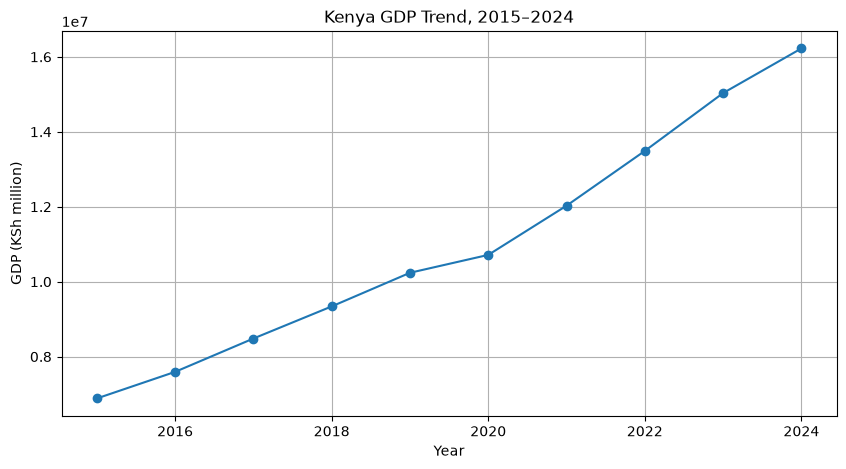

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["gdp_current_ksh_million"],
    marker="o"
)

plt.title("Kenya GDP Trend, 2015–2024")
plt.xlabel("Year")
plt.ylabel("GDP (KSh million)")
plt.grid(True)

plt.show()

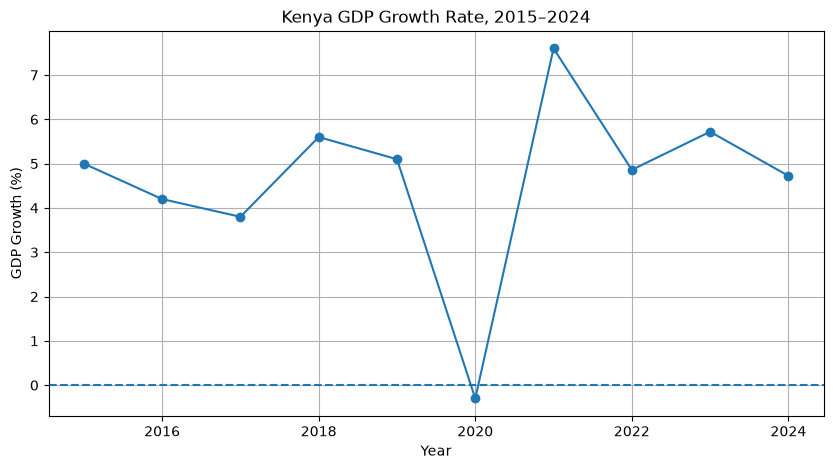

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["gdp_growth_percent"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Kenya GDP Growth Rate, 2015–2024")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)

plt.show()

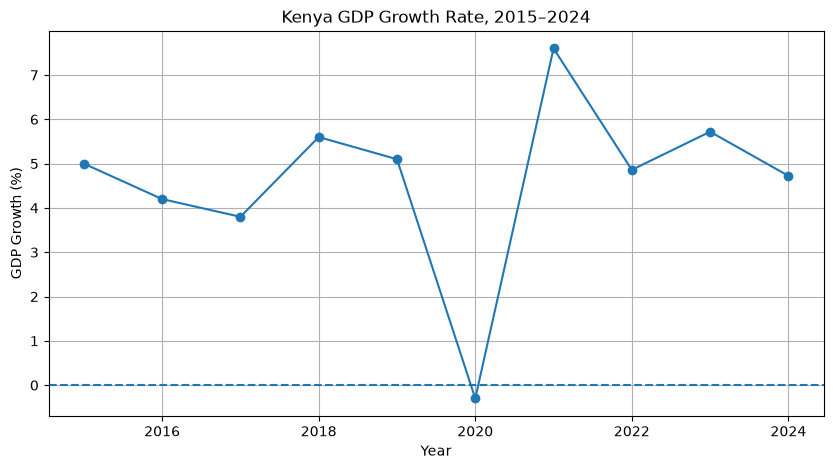

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["gdp_growth_percent"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Kenya GDP Growth Rate, 2015–2024")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)

plt.show()

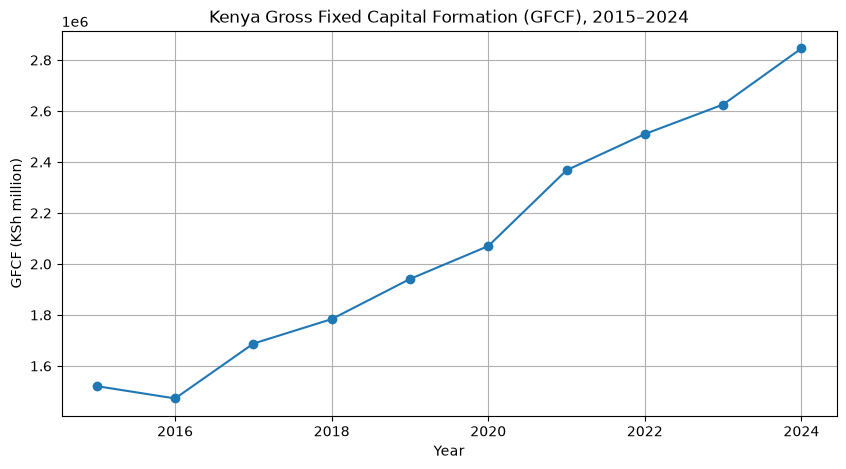

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["gfcf_ksh_million"],
    marker="o"
)

plt.title("Kenya Gross Fixed Capital Formation (GFCF), 2015–2024")
plt.xlabel("Year")
plt.ylabel("GFCF (KSh million)")
plt.grid(True)

plt.show()

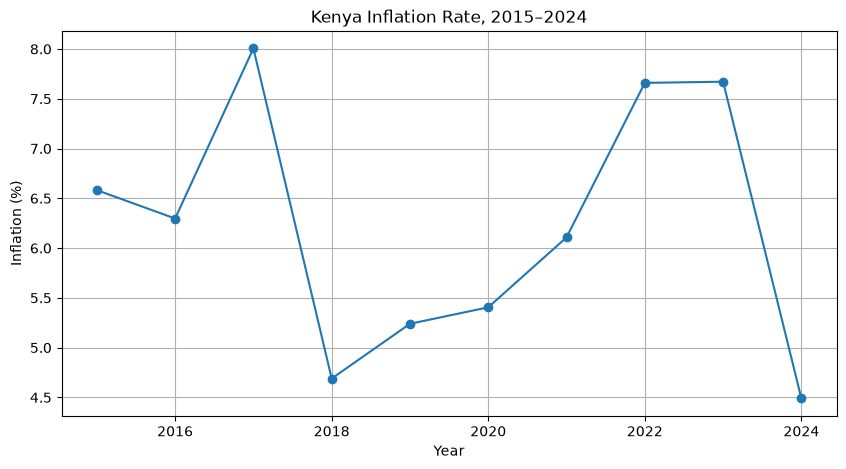

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["inflation_rate_percent"],
    marker="o"
)

plt.title("Kenya Inflation Rate, 2015–2024")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.grid(True)

plt.show()

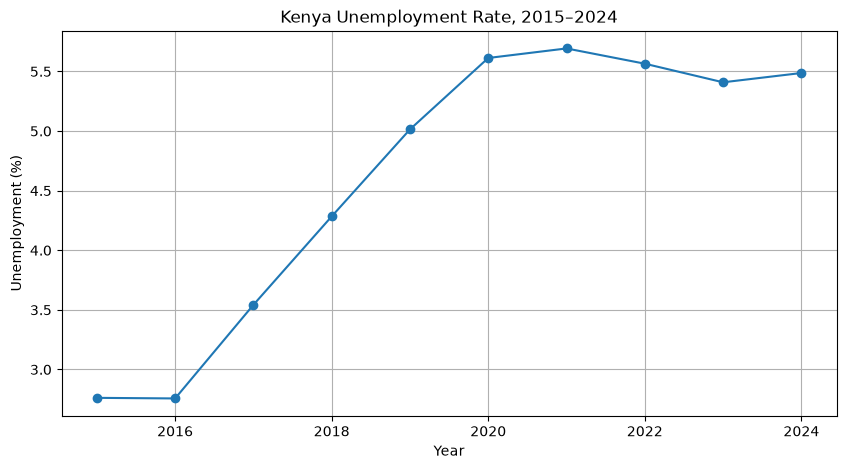

In [54]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_sql["year"],
    df_sql["unemployment_rate_percent"],
    marker="o"
)

plt.title("Kenya Unemployment Rate, 2015–2024")
plt.xlabel("Year")
plt.ylabel("Unemployment (%)")
plt.grid(True)

plt.show()

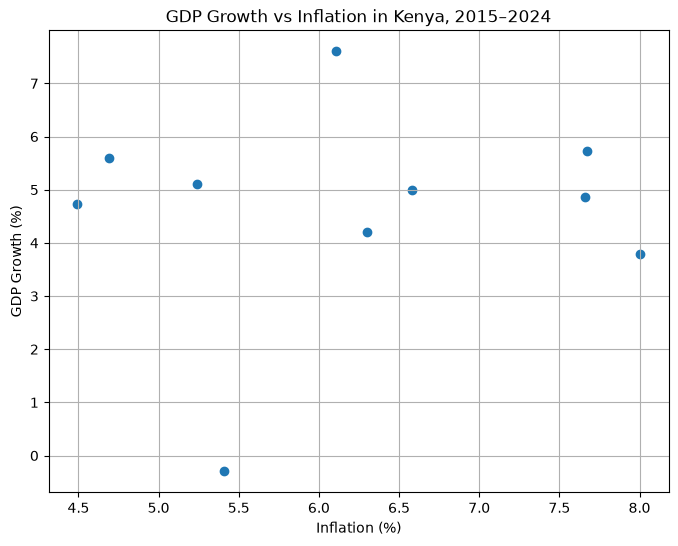

In [55]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_sql["inflation_rate_percent"],
    df_sql["gdp_growth_percent"]
)

plt.title("GDP Growth vs Inflation in Kenya, 2015–2024")
plt.xlabel("Inflation (%)")
plt.ylabel("GDP Growth (%)")
plt.grid(True)

plt.show()

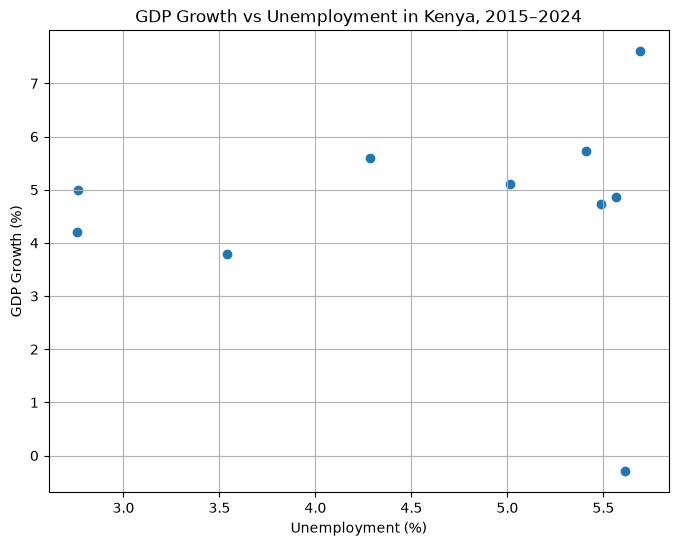

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_sql["unemployment_rate_percent"],
    df_sql["gdp_growth_percent"]
)

plt.title("GDP Growth vs Unemployment in Kenya, 2015–2024")
plt.xlabel("Unemployment (%)")
plt.ylabel("GDP Growth (%)")
plt.grid(True)

plt.show()

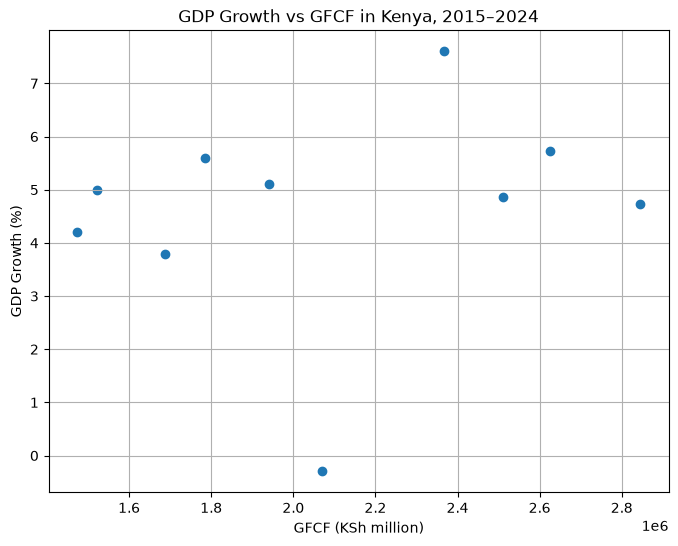

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_sql["gfcf_ksh_million"],
    df_sql["gdp_growth_percent"]
)

plt.title("GDP Growth vs GFCF in Kenya, 2015–2024")
plt.xlabel("GFCF (KSh million)")
plt.ylabel("GDP Growth (%)")
plt.grid(True)

plt.show()

In [58]:
# Create a time-series dataset
forecast_df = df_sql[
    ["year", "gdp_current_ksh_million"]
].copy()

forecast_df = forecast_df.sort_values("year")

display(forecast_df)

,year,gdp_current_ksh_million
0,2015,6884327.0
1,2016,7594064.0
2,2017,8483396.0
3,2018,9340307.0
4,2019,10237727.0
5,2020,10715070.0
6,2021,12027662.0
7,2022,13489642.0
8,2023,15033610.0
9,2024,16224478.0


In [59]:
# Set year as the time-series index
forecast_series = forecast_df.set_index("year")["gdp_current_ksh_million"]

print(forecast_series)

year
2015     6884327.0
2016     7594064.0
2017     8483396.0
2018     9340307.0
2019    10237727.0
2020    10715070.0
2021    12027662.0
2022    13489642.0
2023    15033610.0
2024    16224478.0
Name: gdp_current_ksh_million, dtype: float64


In [60]:
import numpy as np
import statsmodels.api as sm

X = forecast_df[["year"]]
y = forecast_df["gdp_current_ksh_million"]

X = sm.add_constant(X)

trend_model = sm.OLS(y, X).fit()

print(trend_model.summary())

                               OLS Regression Results                              
Dep. Variable:     gdp_current_ksh_million   R-squared:                       0.979
Model:                                 OLS   Adj. R-squared:                  0.977
Method:                      Least Squares   F-statistic:                     381.0
Date:                     Thu, 03 Sep 2026   Prob (F-statistic):           4.93e-08
Time:                             15:10:17   Log-Likelihood:                -143.86
No. Observations:                       10   AIC:                             291.7
Df Residuals:                            8   BIC:                             292.3
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [61]:
future_years = pd.DataFrame({
    "year": range(2025, 2030)
})

future_X = sm.add_constant(future_years)

forecast_values = trend_model.predict(future_X)

forecast_results = pd.DataFrame({
    "year": future_years["year"],
    "forecast_gdp_ksh_million": forecast_values
})

display(forecast_results)

,year,forecast_gdp_ksh_million
0,2025,1.665999e+07
1,2026,1.768853e+07
2,2027,1.871707e+07
3,2028,1.974560e+07
4,2029,2.077414e+07


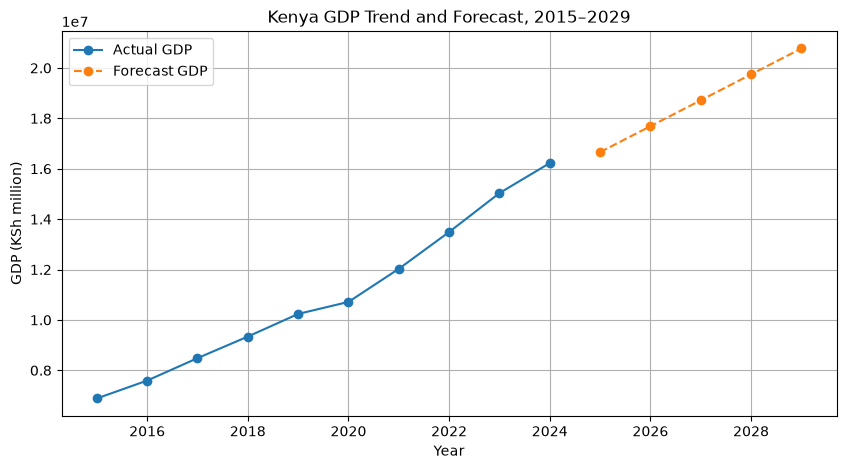

In [62]:
plt.figure(figsize=(10, 5))

plt.plot(
    forecast_df["year"],
    forecast_df["gdp_current_ksh_million"],
    marker="o",
    label="Actual GDP"
)

plt.plot(
    forecast_results["year"],
    forecast_results["forecast_gdp_ksh_million"],
    marker="o",
    linestyle="--",
    label="Forecast GDP"
)

plt.title("Kenya GDP Trend and Forecast, 2015–2029")
plt.xlabel("Year")
plt.ylabel("GDP (KSh million)")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
print("R-squared:", trend_model.rsquared)
print("Adjusted R-squared:", trend_model.rsquared_adj)

R-squared: 0.9794322066139703
Adjusted R-squared: 0.9768612324407167


In [64]:
forecast_results["forecast_growth_percent"] = (
    forecast_results["forecast_gdp_ksh_million"].pct_change() * 100
)

display(forecast_results)

,year,forecast_gdp_ksh_million,forecast_growth_percent
0,2025,1.665999e+07,NaN
1,2026,1.768853e+07,6.173703
2,2027,1.871707e+07,5.814720
3,2028,1.974560e+07,5.495190
4,2029,2.077414e+07,5.208948


In [65]:
# Prepare historical data
historical = df_sql.copy()

historical["data_type"] = "Actual"

# Rename GDP column for consistency
historical = historical.rename(
    columns={
        "gdp_current_ksh_million": "gdp_ksh_million"
    }
)

# Add forecast columns to historical data
historical["forecast_gdp_ksh_million"] = np.nan
historical["forecast_growth_percent"] = np.nan


# Prepare forecast data
forecast_powerbi = forecast_results.copy()

forecast_powerbi["gdp_ksh_million"] = np.nan
forecast_powerbi["gdp_growth_percent"] = np.nan
forecast_powerbi["gfcf_ksh_million"] = np.nan
forecast_powerbi["inflation_rate_percent"] = np.nan
forecast_powerbi["unemployment_rate_percent"] = np.nan
forecast_powerbi["data_type"] = "Forecast"

# Arrange columns
forecast_powerbi = forecast_powerbi[
    [
        "year",
        "gdp_ksh_million",
        "gdp_growth_percent",
        "gfcf_ksh_million",
        "inflation_rate_percent",
        "unemployment_rate_percent",
        "forecast_gdp_ksh_million",
        "forecast_growth_percent",
        "data_type"
    ]
]

historical = historical[
    [
        "year",
        "gdp_ksh_million",
        "gdp_growth_percent",
        "gfcf_ksh_million",
        "inflation_rate_percent",
        "unemployment_rate_percent",
        "forecast_gdp_ksh_million",
        "forecast_growth_percent",
        "data_type"
    ]
]

# Combine actual and forecast data
dashboard_data = pd.concat(
    [historical, forecast_powerbi],
    ignore_index=True
)

display(dashboard_data)

,year,gdp_ksh_million,gdp_growth_percent,gfcf_ksh_million,inflation_rate_percent,unemployment_rate_percent,forecast_gdp_ksh_million,forecast_growth_percent,data_type
0,2015,6884327.0,5.000000,1520817.0,6.582154,2.762,NaN,NaN,Actual
1,2016,7594064.0,4.200000,1472621.0,6.297250,2.757,NaN,NaN,Actual
2,2017,8483396.0,3.800000,1687833.0,8.005650,3.542,NaN,NaN,Actual
3,2018,9340307.0,5.600000,1783811.0,4.689806,4.284,NaN,NaN,Actual
4,2019,10237727.0,5.100000,1941234.0,5.239638,5.014,NaN,NaN,Actual
5,2020,10715070.0,-0.300000,2070321.0,5.405162,5.613,NaN,NaN,Actual
6,2021,12027662.0,7.600000,2367797.0,6.107936,5.693,NaN,NaN,Actual
7,2022,13489642.0,4.859979,2509782.0,7.659863,5.565,NaN,NaN,Actual
8,2023,15033610.0,5.719993,2625440.0,7.671396,5.409,NaN,NaN,Actual
9,2024,16224478.0,4.724740,2845545.0,4.489789,5.487,NaN,NaN,Actual


In [66]:
dashboard_data.to_csv(
    "../processed/kenya_economic_dashboard_data.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.
